### Load the mistral-7b-v0.3 model

Adapted from https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Mistral_v0.3_(7B)-Alpaca.ipynb

In [1]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! We auto support RoPE Scaling internally!
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/mistral-7b-bnb-4bit",
    "unsloth/mistral-7b-instruct-v0.2-bnb-4bit",
    "unsloth/llama-2-7b-bnb-4bit",
    "unsloth/llama-2-13b-bnb-4bit",
    "unsloth/codellama-34b-bnb-4bit",
    "unsloth/tinyllama-bnb-4bit",
    "unsloth/gemma-7b-bnb-4bit", # New Google 6 trillion tokens model 2.5x faster!
    "unsloth/gemma-2b-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/mistral-7b-v0.3", # Choose ANY! eg teknium/OpenHermes-2.5-Mistral-7B
    # model_name = "unsloth/mistral-7b-bnb-4bit",
    # model_name = "unsloth/tinyllama", # https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/TinyLlama_(1.1B)-Alpaca.ipynb
    # model_name = "microsoft/phi-2", # https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/TinyLlama_(1.1B)-Alpaca.ipynb
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.4.3: Fast Mistral patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.568 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


### Add LoRA adapters

In [2]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
)

Unsloth 2025.4.3 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


### Data preparation

In [4]:
from datasets import load_dataset
train_dataset, test_dataset = load_dataset("json", data_files={"train": "dataset-for-finetuning-sentences-train.json", "test": "dataset-for-finetuning-sentences-test.json"}, split=["train", "test"])

In [5]:
# the whole dataset consists of 1000 samples, 200 different scripts with 5 variations each.
# i.e. the test dataset consists of 200 samples, 40 different scripts with 5 variations each, so we pick every 5th
test_dataset = test_dataset.select(range(0, 100, 5))

In [6]:
print(test_dataset[1]['rephrased'])

To configure the specified channel, referred to as 'c3RKg1L', here are the necessary settings:

1. Excite the fluorophore using a light source with a wavelength of 385 nanometers and an intensity of 4%.
2. Set the camera exposure time, or the illumination time, to 6890 milliseconds.

Make sure to adjust your equipment accordingly for a successful experiment using this channel setting.


In [7]:
print(test_dataset)

Dataset({
    features: ['sentence', 'rephrased', 'context'],
    num_rows: 20
})


In [8]:
prompt = '''
Below is the description of a microscope timelapse experiment. Transfer this description into valid microscope-nlScript code.

### Instruction:
{}

### Input:
{}

### Response:
{}
'''

EOS_TOKEN = tokenizer.eos_token # Must add EOS_TOKEN

def apply_chat_template(example):
    sentence  = example['sentence']
    rephrased = example['rephrased']
    context   = example['context']
    example['text'] = prompt.format(rephrased, context, sentence) + EOS_TOKEN
    return example

column_names = list(train_dataset.features)

processed_train_dataset = train_dataset.map(
    apply_chat_template,
    remove_columns=column_names,
    desc="Applying chat template to train",
)

processed_test_dataset = test_dataset.map(
    apply_chat_template,
    remove_columns=column_names,
    desc="Applying chat template to test",
)

Applying chat template to train:   0%|          | 0/1600 [00:00<?, ? examples/s]

Applying chat template to test:   0%|          | 0/20 [00:00<?, ? examples/s]

In [9]:
print(processed_train_dataset[0]['text'])


Below is the description of a microscope timelapse experiment. Transfer this description into valid microscope-nlScript code.

### Instruction:
To define the region referred to as 'Q1G', follow these instructions:

1. Set the dimensions of the region as follows:
   - Width: 30.837 micrometers
   - Height: 226.531 micrometers
   - Depth: 460.6 micrometers

2. Determine the center of the region using the given 3D stage position:
   - x-coordinate: 190.491 micrometers
   - y-coordinate: 599.181 micrometers
   - z-coordinate: 503.437 micrometers

So, the region named 'Q1G' is a cuboid with the specified dimensions and centered at the given coordinates.

### Input:
// The following sentence describes the configuration of a channel, i.e. the settings needed 
// for exciting a specific fluorophore or for illuminating a brightfield image.
// The name of the channel is 'g0TyXG', the wavelength of the 
// light source (led or laser) is 567nm (nanometers), the intensity (power) of the 
// light 

### Train the model

In [10]:
print(tokenizer)

LlamaTokenizerFast(name_or_path='unsloth/mistral-7b-v0.3-bnb-4bit', vocab_size=32768, model_max_length=32768, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '[control_768]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[INST]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[/INST]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("[TOOL_CALLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("[AVAILABLE_TO

In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = processed_train_dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        # max_steps = 60, # Set num_train_epochs = 1 for full training runs
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc
        # https://www.reddit.com/r/unsloth/comments/1bnm3yd/validation_dataset/
        fp16_full_eval = True,
        per_device_eval_batch_size = 2,
        eval_accumulation_steps = 4,
        eval_strategy = "steps",
        eval_steps = 5,
        do_eval = True,
    ),
    eval_dataset = processed_test_dataset,
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1600 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/20 [00:00<?, ? examples/s]

#### Show current memory stats

In [12]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.568 GB.
7.0 GB of memory reserved.


In [13]:
# https://unsloth.ai/blog/gradient
from unsloth import unsloth_train
# trainer_stats = trainer.train() << Buggy gradient accumulation
trainer_stats = unsloth_train(trainer)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040/7,000,000,000 (0.60% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
5,0.892900,0.793206
10,0.462600,0.403308
15,0.368700,0.361072
20,0.357400,0.345512
25,0.336700,0.338520
30,0.348000,0.336416
35,0.341800,0.332263
40,0.356700,0.331303
45,0.316700,0.329792
50,0.332500,0.328526


Unsloth: Not an error, but MistralForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [20]:
import json

with open("outputs/checkpoint-100/trainer_state.json", "r") as f:
    logs = json.load(f)

In [21]:
train_loss = []
eval_loss = []
for l in logs['log_history']:
    step = l['step']
    try:
        train_loss.append((step, l['loss']))
    except:
        pass
    try:
        eval_loss.append((step, l['eval_loss']))
    except:
        pass

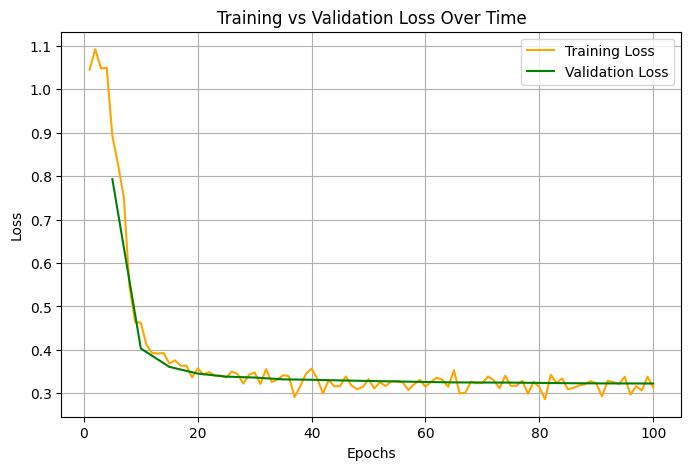

In [22]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Loss
# https://stackoverflow.com/questions/21519203/plotting-a-list-of-x-y-coordinates
plt.figure(figsize=(8, 5))
plt.plot(*zip(*train_loss), marker="", label="Training Loss", color="orange")
plt.plot(*zip(*eval_loss), marker="", label="Validation Loss", color="green")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Over Time")
plt.legend()
plt.grid(True)
plt.show()

### Save the model in SafeTensor format

#### Adapters

In [15]:
model.save_pretrained("results/sentence-adapters")  # Local saving
tokenizer.save_pretrained("results/sentence-adapters")

('results/sentence-adapters/tokenizer_config.json',
 'results/sentence-adapters/special_tokens_map.json',
 'results/sentence-adapters/tokenizer.model',
 'results/sentence-adapters/added_tokens.json',
 'results/sentence-adapters/tokenizer.json')

In [16]:
import shutil
shutil.make_archive("results/Lora_Adapters", 'zip', "results/sentence-adapters")

'/data/share/unsloth/mistral/results/Lora_Adapters.zip'

### Use the trained model for prediction

In [1]:
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name = "outputs/checkpoint-60",
    model_name = "results/sentence-adapters",
    # model_name = "results/adapters-4bnb",
    # model_name = "results/merged",
    max_seq_length = 4096,
    dtype = None,
    load_in_4bit = True
)
FastLanguageModel.for_inference(model);



🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.4.3: Fast Mistral patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.568 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth: Will load results/sentence-adapters as a legacy tokenizer.
Unsloth 2025.4.3 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [3]:
from datasets import load_dataset
train_dataset, test_dataset = load_dataset("json", data_files={"train": "dataset-for-finetuning-sentences-train.json", "test": "dataset-for-finetuning-sentences-test.json"}, split=["train", "test"])

In [4]:
prompt = '''
Below is the description of a microscope timelapse experiment. Transfer this description into valid English microscope-nlScript code.

### Instruction:
{}

### Input:
{}

### Response:
{}
'''

EOS_TOKEN = tokenizer.eos_token # Must add EOS_TOKEN

In [6]:
sample = prompt.format(test_dataset[0]['rephrased'], test_dataset[0]['context'], "")
print(sample)

inputs = tokenizer([sample], return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=2048, use_cache = True)
r = tokenizer.batch_decode(outputs)


Below is the description of a microscope timelapse experiment. Transfer this description into valid English microscope-nlScript code.

### Instruction:
To begin the image acquisition process, wait for a delay of 8.3 hours. Once the specified time has passed, follow these steps:

1. Acquire images for all defined positions.
2. Capture images for all defined channels.
3. Set the plane distance, also known as the z-step, to 14.3 microns.
4. Use the 5x objective lens, combined with the 0.5x magnification changer.
5. Set the camera binning to 4 x 4 pixels.

In summary, when the 8.3-hour delay is over, capture images for all positions, channels, with a plane distance of 14.3 microns, using the 5x lens with the 0.5x magnification changer and a binning of 4 x 4 pixels.

### Input:
// The following sentence describes the configuration of a channel, i.e. the settings needed 
// for exciting a specific fluorophore or for illuminating a brightfield image.
// The name of the channel is 'xaX', the 

In [8]:
print(model.generation_config.to_dict())

{'max_length': 32768, 'max_new_tokens': None, 'min_length': 0, 'min_new_tokens': None, 'early_stopping': False, 'max_time': None, 'stop_strings': None, 'do_sample': False, 'num_beams': 1, 'num_beam_groups': 1, 'penalty_alpha': None, 'dola_layers': None, 'use_cache': True, 'cache_implementation': None, 'cache_config': None, 'return_legacy_cache': None, 'prefill_chunk_size': None, 'temperature': 1.0, 'top_k': 50, 'top_p': 1.0, 'min_p': None, 'typical_p': 1.0, 'epsilon_cutoff': 0.0, 'eta_cutoff': 0.0, 'diversity_penalty': 0.0, 'repetition_penalty': 1.0, 'encoder_repetition_penalty': 1.0, 'length_penalty': 1.0, 'no_repeat_ngram_size': 0, 'bad_words_ids': None, 'force_words_ids': None, 'renormalize_logits': False, 'constraints': None, 'forced_bos_token_id': None, 'forced_eos_token_id': None, 'remove_invalid_values': False, 'exponential_decay_length_penalty': None, 'suppress_tokens': None, 'begin_suppress_tokens': None, 'forced_decoder_ids': None, 'sequence_bias': None, 'token_healing': Fals